# <div style="text-align: center;">*CAR  PRICE  PREDICTION.*</div>

# PHASE 1 - EDA.

- # DATA EXPLORATION.

In [2]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# load the dataset

df = pd.read_csv('../datasets/car data.csv')

In [4]:
# explore the dataset

print('                                                   TOP 5 ROWS OF THE DATASET\n'                               )
print(df.head())
print('\n                                                   BOTTOM 5 ROWS OF THE DATASET\n'                               )
print(df.tail())
print('\n                                                   DATASET INFORMATION\n'                               )
print(df.info())
print('\n                                                   DATASET DESCRIPTION\n'                               )
print(df.describe())
print('\n                                                   DATASET SHAPE\n'                               )
print(df.shape)





                                                   TOP 5 ROWS OF THE DATASET

  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  

                                                   BOTTOM 5 ROWS OF THE DATASET

    Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
296     city  2016           9.50           11.6       33988    Diesel   
297     brio  2015           4.00    

# key insights from the above exploration are:
- The dataset contains 301 rows and 9 columns.
- The dataset contains both numerical and categorical features.
- The target variable is 'Selling_Price', which is a numerical feature.




In [5]:
# check for missing values and duplicates in the dataset.

print('\n                                                   MISSING VALUES IN THE DATASET\n'                               )
print(df.isnull().sum())
print('\n                                                   DUPLICATE VALUES IN THE DATASET\n'                               )
print('Duplicated Values:',df.duplicated().sum())
duplicates = df[df.duplicated(keep=False)]
print("Duplicate rows:")
print(duplicates)
print('\n                                                   AFTER REMOVING DUPLICATES VALUES\n'                               )
print(df.drop_duplicates(inplace=True))
print('Duplicated values after removing duplicates:',df.duplicated().sum())





                                                   MISSING VALUES IN THE DATASET

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

                                                   DUPLICATE VALUES IN THE DATASET

Duplicated Values: 2
Duplicate rows:
    Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
15    ertiga  2016           7.75          10.79       43000    Diesel   
17    ertiga  2016           7.75          10.79       43000    Diesel   
51  fortuner  2015          23.00          30.61       40000    Diesel   
93  fortuner  2015          23.00          30.61       40000    Diesel   

   Selling_type Transmission  Owner  
15       Dealer       Manual      0  
17       Dealer       Manual      0  
51       Dealer    Automatic      0  
93       Dealer    Automatic      0  

                                                 

# key insights from the above exploration are:

- There are no missing values in the dataset.
- There are 2 duplicate rows in the dataset, which have been removed.


In [6]:
# let's get the value counts of the categorical features in the dataset.

print('\n                                                   VALUE COUNTS OF THE CATEGORICAL FEATURES\n'                               )
categorical_features = ['Fuel_Type', 'Seller_Type', 'Transmission']
print('Value counts of Fuel_Type:\n',df['Fuel_Type'].value_counts())
print('\nValue counts of Seller_Type:\n',df['Selling_type'].value_counts())
print('\nValue counts of Transmission:\n',df['Transmission'].value_counts())


                                                   VALUE COUNTS OF THE CATEGORICAL FEATURES

Value counts of Fuel_Type:
 Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64

Value counts of Seller_Type:
 Selling_type
Dealer        193
Individual    106
Name: count, dtype: int64

Value counts of Transmission:
 Transmission
Manual       260
Automatic     39
Name: count, dtype: int64


In [7]:
df.head(10)

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
5,vitara brezza,2018,9.25,9.83,2071,Diesel,Dealer,Manual,0
6,ciaz,2015,6.75,8.12,18796,Petrol,Dealer,Manual,0
7,s cross,2015,6.50,8.61,33429,Diesel,Dealer,Manual,0
8,ciaz,2016,8.75,8.89,20273,Diesel,Dealer,Manual,0
9,ciaz,2015,7.45,8.92,42367,Diesel,Dealer,Manual,0


In [8]:
# let's extarct the 'Year' column from the dataset and create a new column called 'Car_Age' which will represent the age of the car.

print('\n                                                   CAR AGE COLUMN\n'                               )
df['Car_Age'] = 2026 - df['Year']
print(df[['Year', 'Car_Age']].head(10))



                                                   CAR AGE COLUMN

   Year  Car_Age
0  2014       12
1  2013       13
2  2017        9
3  2011       15
4  2014       12
5  2018        8
6  2015       11
7  2015       11
8  2016       10
9  2015       11


In [9]:
# now let's drop the 'Year' column from the dataset.

df.drop('Year', axis=1, inplace=True)

# DATA VISUALIZATION.

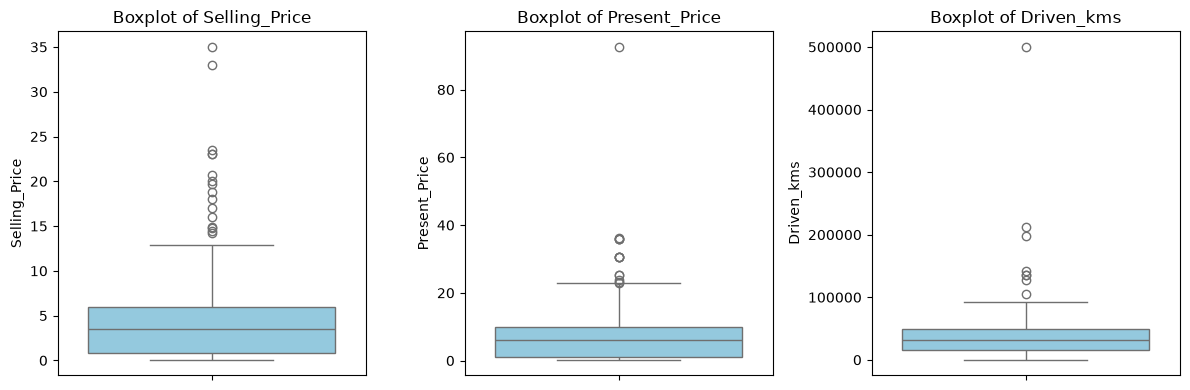

In [15]:
# let's check for any outliers in the dataset using boxplots.

num_cols = ['Selling_Price', 'Present_Price', 'Driven_kms']
plt.figure(figsize=(12, 4))
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [12]:
# let's deal with these outliers

# log transformation.
print('\n                                                   LOG TRANSFORMATION\n'                               )
df['Selling_Price_log'] = np.log1p(df['Selling_Price'])
df['Present_Price_log'] = np.log1p(df['Present_Price'])
df['Driven_kms_log'] = np.log1p(df['Driven_kms'])



                                                   LOG TRANSFORMATION



In [13]:
df[['Selling_Price', 'Selling_Price_log' , 'Present_Price' , 'Present_Price_log' , 'Driven_kms' , 'Driven_kms_log']].head(10)

,Selling_Price,Selling_Price_log,Present_Price,Present_Price_log,Driven_kms,Driven_kms_log
0,3.35,1.470176,5.59,1.885553,27000,10.203629
1,4.75,1.749200,9.54,2.355178,43000,10.668979
2,7.25,2.110213,9.85,2.384165,6900,8.839422
3,2.85,1.348073,4.15,1.638997,5200,8.556606
4,4.60,1.722767,6.87,2.063058,42450,10.656106
5,9.25,2.327278,9.83,2.382320,2071,7.636270
6,6.75,2.047693,8.12,2.210470,18796,9.841453
7,6.50,2.014903,8.61,2.262804,33429,10.417209
8,8.75,2.277267,8.89,2.291524,20273,9.917095
9,7.45,2.134166,8.92,2.294553,42367,10.654149


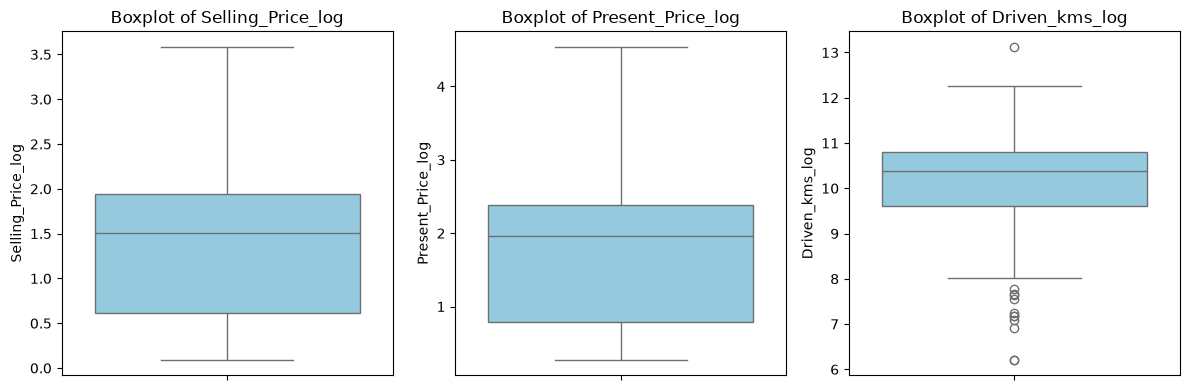

In [14]:
# let's check for any outliers in the dataset using boxplots.

num_cols = ['Selling_Price_log', 'Present_Price_log', 'Driven_kms_log']
plt.figure(figsize=(12, 4))
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

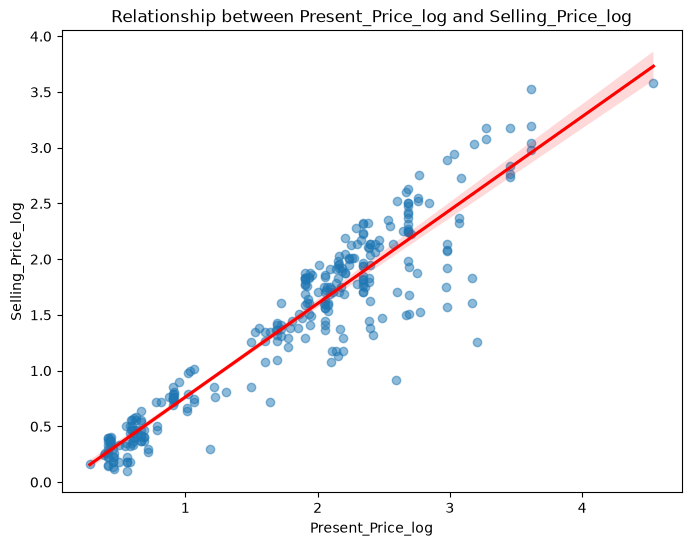

In [ ]:
# let's check the relationship between the Selling Price and Present Price in the dataset using a regplot.

plt.figure(figsize=(8, 6))
sns.regplot(x='Present_Price_log', y='Selling_Price_log', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Relationship between Present_Price_log and Selling_Price_log')
plt.xlabel('Present_Price_log')
plt.ylabel('Selling_Price_log')
plt.show()

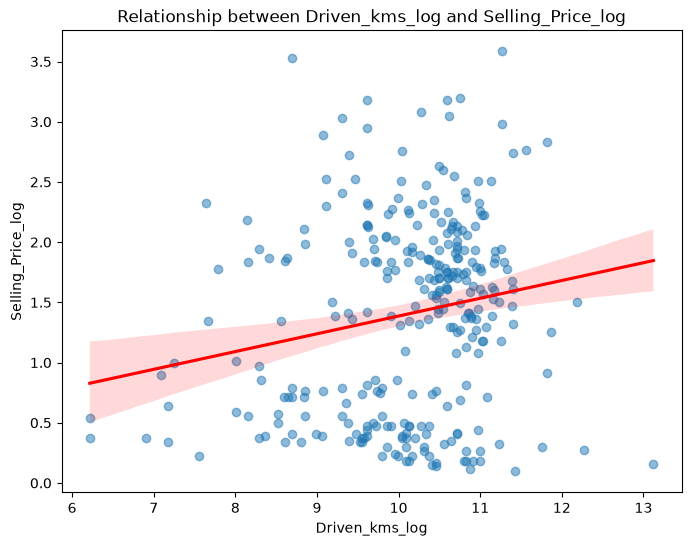

In [20]:
# let's check the relationship between the Selling Price and Driven kms in the dataset using a regplot.


plt.figure(figsize=(8, 6))
sns.regplot(x='Driven_kms_log', y='Selling_Price_log', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Relationship between Driven_kms_log and Selling_Price_log')
plt.xlabel('Driven_kms_log')
plt.ylabel('Selling_Price_log')
plt.show()


C:\Users\Khurshid Computers\AppData\Local\Temp\ipykernel_6656\2231645566.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Fuel_Type', y='Selling_Price_log', data=df, palette='viridis')


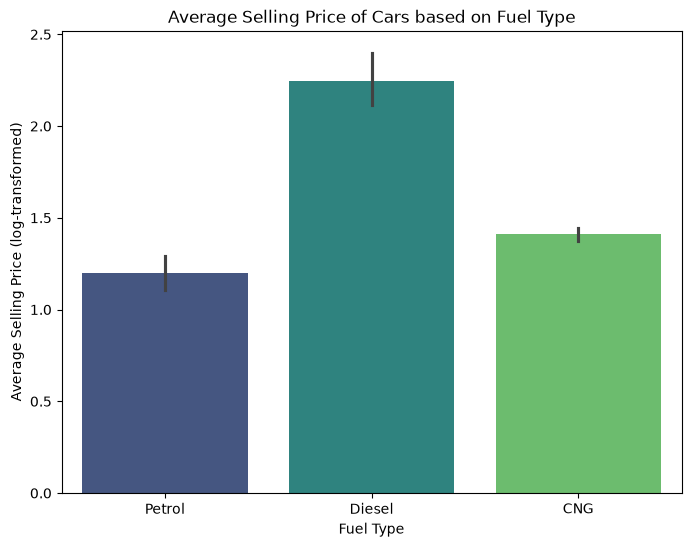

In [21]:
# let's make a barplot to visualize the average Selling Price of cars based on their Fuel Type.

plt.figure(figsize=(8, 6))
sns.barplot(x='Fuel_Type', y='Selling_Price_log', data=df, palette='viridis')
plt.title('Average Selling Price of Cars based on Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Average Selling Price (log-transformed)')
plt.show()

C:\Users\Khurshid Computers\AppData\Local\Temp\ipykernel_6656\1046521542.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Selling_type', y='Selling_Price_log', data=df, palette='magma')


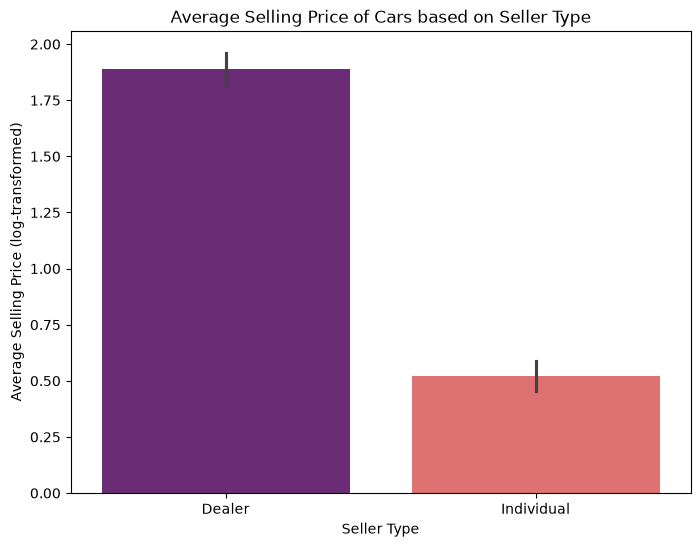

In [23]:
# let's make a barplot to visualize the average Selling Price for each seller type in the dataset.

plt.figure(figsize=(8, 6))
sns.barplot(x='Selling_type', y='Selling_Price_log', data=df, palette='magma')
plt.title('Average Selling Price of Cars based on Seller Type')
plt.xlabel('Seller Type')
plt.ylabel('Average Selling Price (log-transformed)')
plt.show()

C:\Users\Khurshid Computers\AppData\Local\Temp\ipykernel_6656\1773633109.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Transmission', y='Selling_Price_log', data=df, palette='magma')


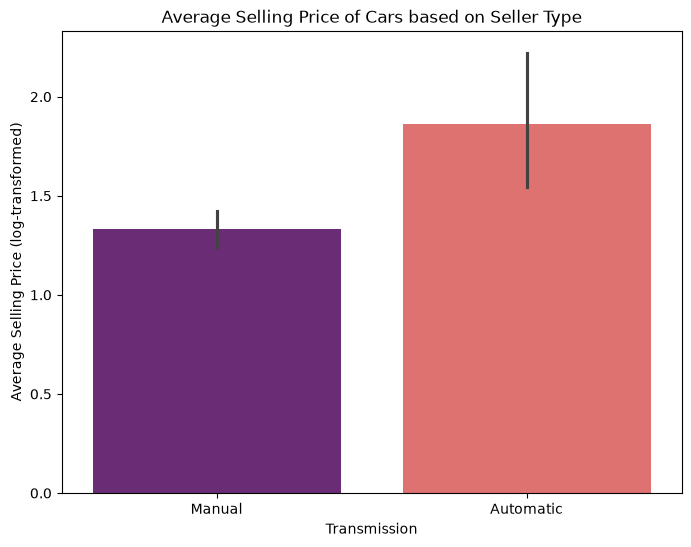

In [25]:
# let's make a barplot to visualize the average Selling Price for each transmission in the dataset.

plt.figure(figsize=(8, 6))
sns.barplot(x='Transmission', y='Selling_Price_log', data=df, palette='magma')
plt.title('Average Selling Price of Cars based on Seller Type')
plt.xlabel('Transmission')
plt.ylabel('Average Selling Price (log-transformed)')
plt.show()


In [26]:
from scipy.stats import shapiro 

num_cols = ['Selling_Price_log', 'Present_Price_log', 'Driven_kms_log']
for col in num_cols:
    stat, p = shapiro(df[col])
    print(col)
    print('p-value', p)
    if p > 0.05:
        print('Approx norm distributed')
    else:
        print('Not norm distributed')    

Selling_Price_log
p-value 7.159893649523637e-08
Not norm distributed
Present_Price_log
p-value 2.2704560595410356e-10
Not norm distributed
Driven_kms_log
p-value 1.4983471851068093e-10
Not norm distributed


<Axes: xlabel='Selling_Price_log', ylabel='Count'>

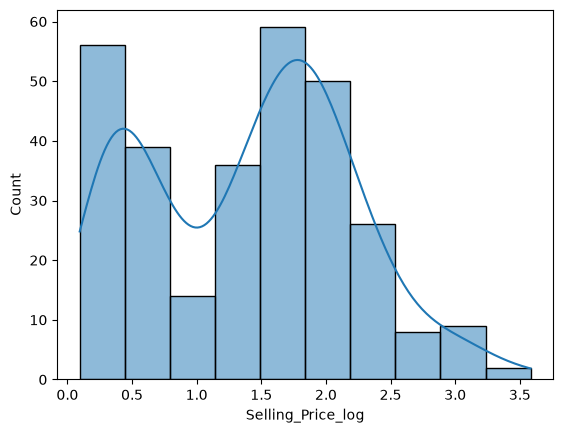

In [27]:
sns.histplot(df['Selling_Price_log'], kde=True)

<Axes: xlabel='Selling_Price_log', ylabel='Count'>

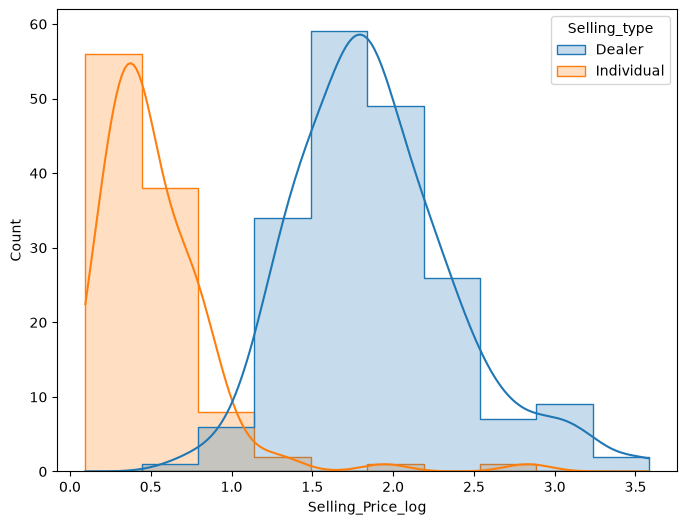

In [30]:
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='Selling_Price_log', hue='Selling_type', kde=True, element='step')


<Axes: xlabel='Present_Price_log', ylabel='Count'>

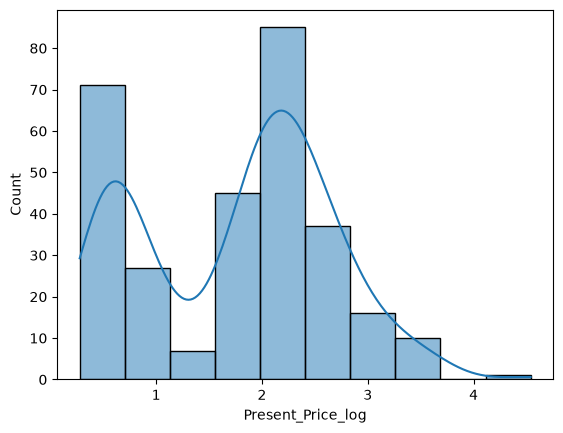

In [28]:
sns.histplot(df['Present_Price_log'], kde=True)

<Axes: xlabel='Driven_kms_log', ylabel='Count'>

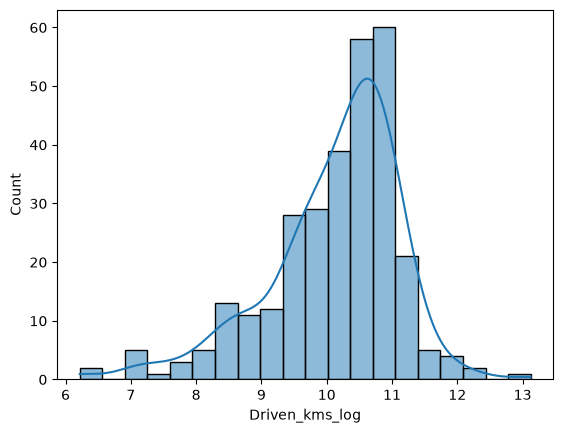

In [29]:
sns.histplot(df['Driven_kms_log'], kde=True)

# SAVE THE CLEANED DATA.

In [31]:
# save the cleaned dataset to a new CSV file.

df.to_csv('car_data_cleaned.csv', index=False)